<a href="https://colab.research.google.com/github/ehmen-khalid/LCA-Regression-Analysis-2/blob/main/Random%20forest%20regression%20analysis%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving lca_data.csv to lca_data (1).csv
Dataset Shape: (54, 14)

Column Names:
['Bottle Material type', 'Filled material', 'Cap material', 'Label', 'Mass (kg)', 'No of uses', 'Transport mode', 'Transport distance (km)', 'Manufacturing process', 'EOL _scenerio', 'EOL (%)', 'Electricity mix', 'Electricity value (kWh)', 'GWP (kg CO2 eq)']

Data Types:
Bottle Material type        object
Filled material             object
Cap material                object
Label                       object
Mass (kg)                  float64
No of uses                 float64
Transport mode              object
Transport distance (km)      int64
Manufacturing process       object
EOL _scenerio               object
EOL (%)                    float64
Electricity mix             object
Electricity value (kWh)    float64
GWP (kg CO2 eq)            float64
dtype: object

Missing Values:
Bottle Material type       0
Filled material            0
Cap material               0
Label                      0
Mass (kg)   

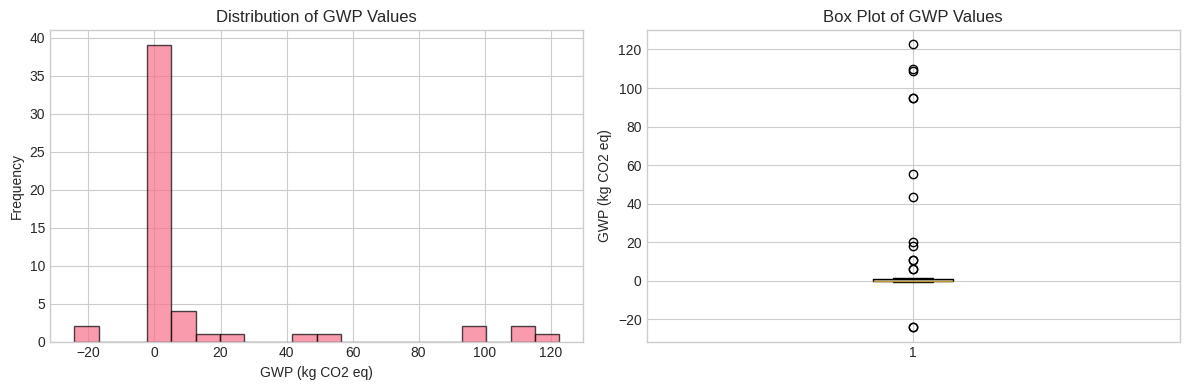


GWP Range: -24.3000 to 122.6000

Shape after One-Hot Encoding: (54, 33)
New columns added:
['Bottle Material type_Amber glass', 'Bottle Material type_Bio-based PET', 'Bottle Material type_Glass', 'Bottle Material type_PET', 'Bottle Material type_PLA', 'Filled material_Sparkling Water', 'Filled material_Water', 'Filled material_no', 'Cap material_Aluminium', 'Cap material_HDPE', 'Cap material_no', 'Label_PE', 'Label_Paper', 'Label_no', 'Transport mode_Truck', 'Transport mode_no', 'EOL _scenerio_Landfilling', 'EOL _scenerio_Non-Returnable', 'EOL _scenerio_Recycling', 'EOL _scenerio_Returnable', 'EOL _scenerio_Reuse', 'EOL _scenerio_no', 'Electricity mix_Medium voltage, Europe', 'Electricity mix_Medium voltage, Italy', 'Electricity mix_Medium voltage, Poland', 'Electricity mix_Medium voltage, Portugal']

Final feature count: 32

Feature columns:
['Mass (kg)', 'No of uses', 'Transport distance (km)', 'Manufacturing process', 'EOL (%)', 'Electricity value (kWh)', 'Bottle Material type_Ambe

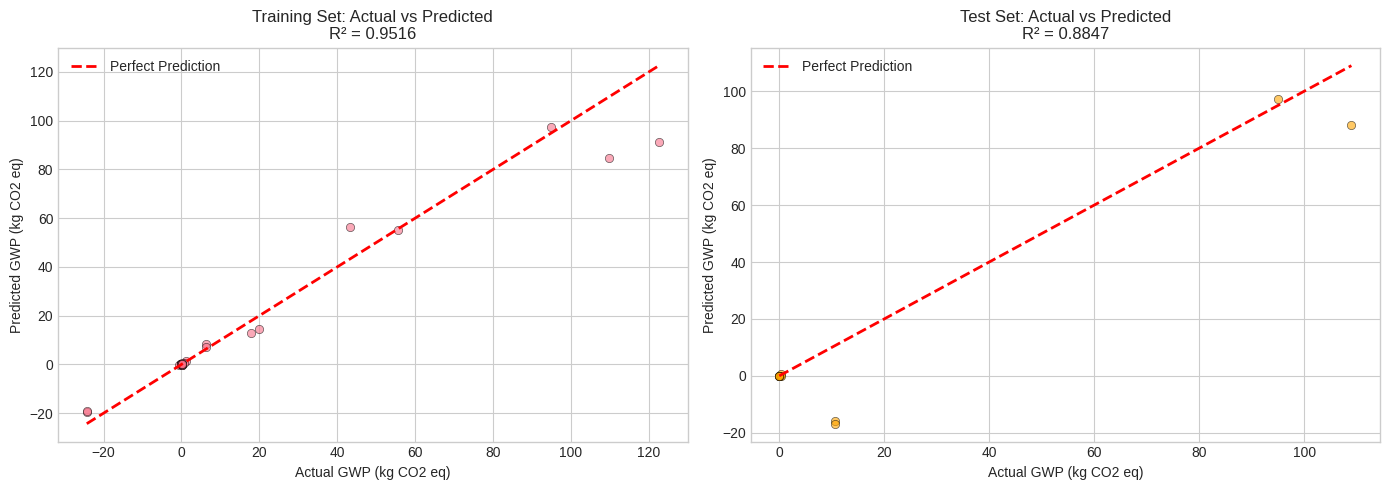

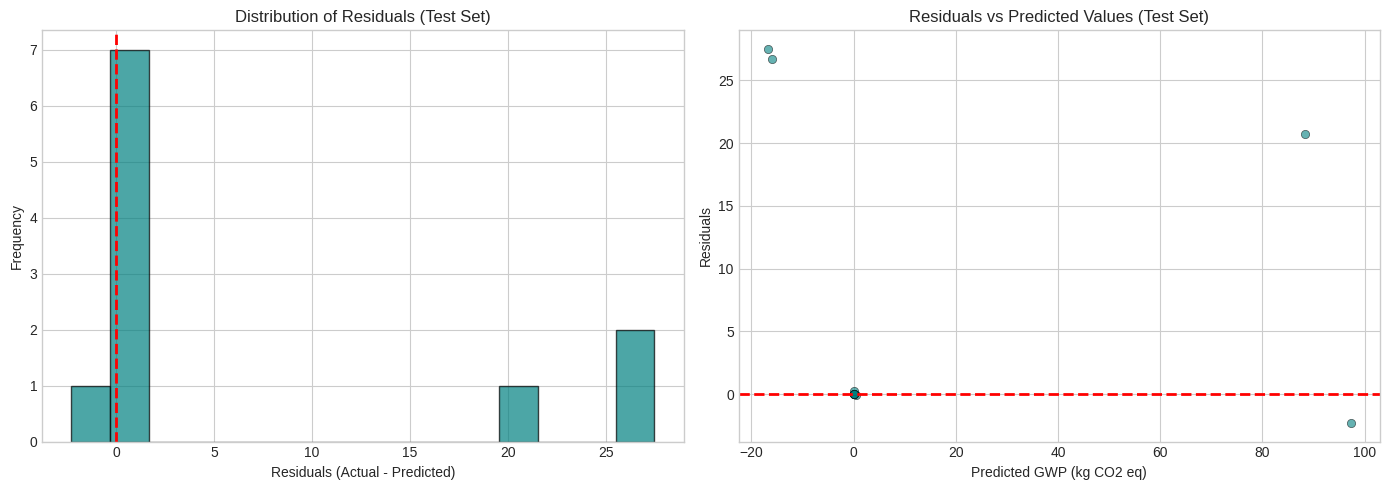

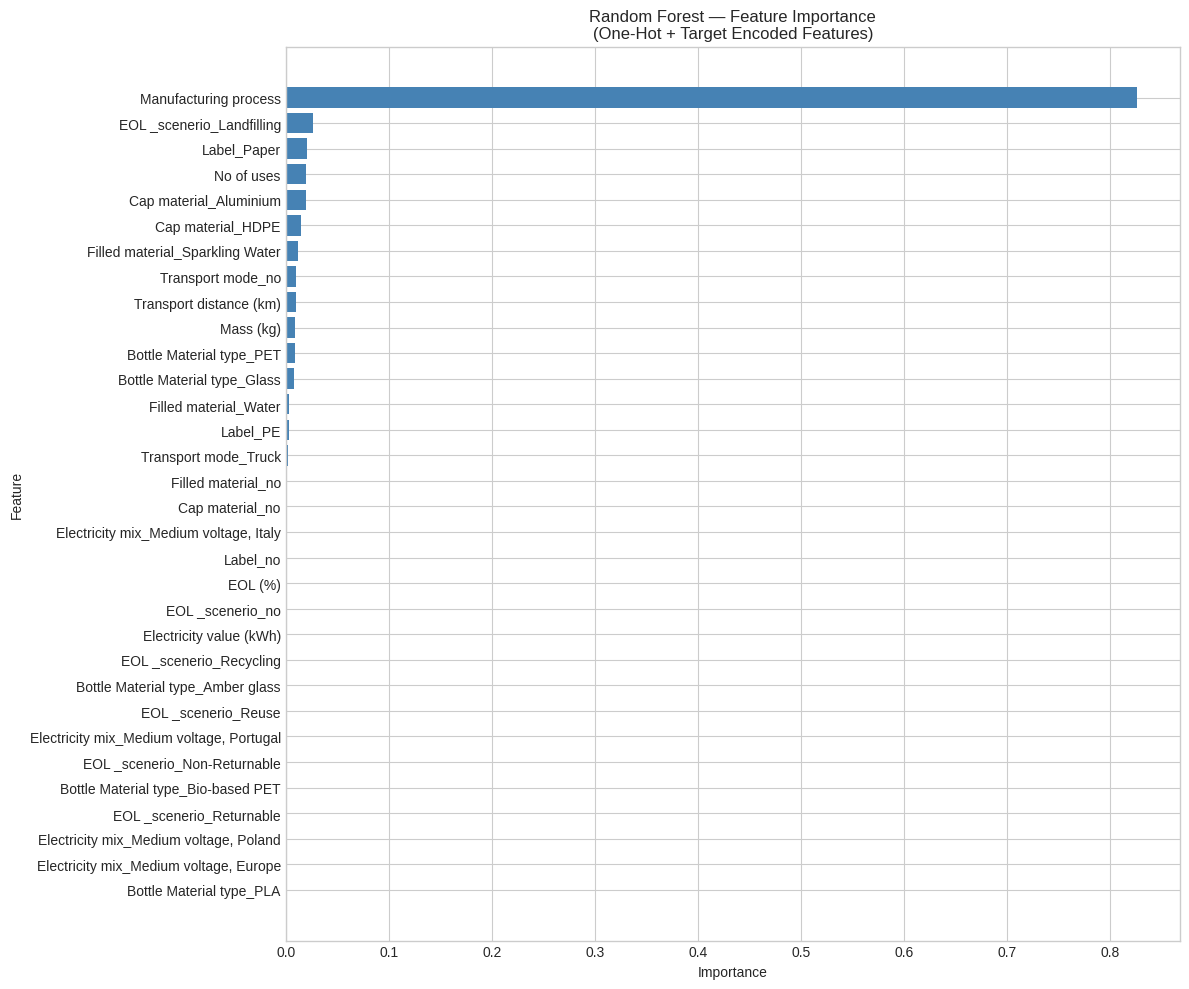


Top 10 Most Important Features:
                        Feature  Importance
          Manufacturing process    0.826482
      EOL _scenerio_Landfilling    0.026634
                    Label_Paper    0.020965
                     No of uses    0.019866
         Cap material_Aluminium    0.019349
              Cap material_HDPE    0.015150
Filled material_Sparkling Water    0.011779
              Transport mode_no    0.010259
        Transport distance (km)    0.009774
                      Mass (kg)    0.009503

  RANDOM FOREST REGRESSION — FINAL RESULTS
  Dataset:            54 samples
  Features (raw):     13 columns
  Features (encoded): 32 columns
  Training samples:   43
  Test samples:       11

  Encoding used:
    • One-Hot Encoding → 7 nominal columns
    • Target Encoding  → Manufacturing process (32 categories)

  Test Set Performance:
    R² Score : 0.8847
    RMSE     : 13.1459 kg CO2 eq
    MAE      : 7.0454 kg CO2 eq


In [1]:
"""
LCA - Global Warming Potential (GWP) Prediction
Random Forest Regression | Corrected Encoding Pipeline
"""

# ==============================================================
# 1. IMPORTS
# ==============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import TargetEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")


# ==============================================================
# 2. DATA LOADING & EXPLORATION
# ==============================================================
uploaded = files.upload()  # A file picker will appear — select your lca_data.csv
df = pd.read_csv('lca_data.csv')  # FIXED: read_csv for .csv file

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe())

# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['GWP (kg CO2 eq)'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('GWP (kg CO2 eq)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of GWP Values')
axes[1].boxplot(df['GWP (kg CO2 eq)'])
axes[1].set_ylabel('GWP (kg CO2 eq)')
axes[1].set_title('Box Plot of GWP Values')
plt.tight_layout()
plt.show()
print(f"\nGWP Range: {df['GWP (kg CO2 eq)'].min():.4f} to {df['GWP (kg CO2 eq)'].max():.4f}")


# ==============================================================
# 3. DATA PREPROCESSING — CORRECTED ENCODING
# ==============================================================
TARGET_COL = 'GWP (kg CO2 eq)'
HIGH_CARD_COL = 'Manufacturing process'   # 32 unique values → Target Encoding

NOMINAL_COLS = [
    'Bottle Material type',
    'Filled material',
    'Cap material',
    'Label',
    'Transport mode',
    'EOL _scenerio',
    'Electricity mix',
]

# --- Step 1: One-Hot Encode nominal columns ---
df_processed = pd.get_dummies(df, columns=NOMINAL_COLS, drop_first=False)

print("\nShape after One-Hot Encoding:", df_processed.shape)
print("New columns added:")
new_cols = [c for c in df_processed.columns if c not in df.columns]
print(new_cols)

# --- Step 2: Separate X and y ---
X = df_processed.drop(columns=[TARGET_COL])
y = df_processed[TARGET_COL]

# --- Step 3: Target Encode 'Manufacturing process' ---
te = TargetEncoder(smooth='auto', random_state=42)
X[HIGH_CARD_COL] = te.fit_transform(X[[HIGH_CARD_COL]], y).ravel()

print("\nFinal feature count:", X.shape[1])
print("\nFeature columns:")
print(X.columns.tolist())
print("\nSample of processed data:")
print(X.head())


# ==============================================================
# 4. TRAIN / TEST SPLIT
# ==============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")


# ==============================================================
# 5. MODEL TRAINING — RANDOM FOREST REGRESSOR
# ==============================================================
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Model trained successfully!")
print(f"  Trees:     {rf_model.n_estimators}")
print(f"  Max depth: {rf_model.max_depth}")

# Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred  = rf_model.predict(X_test)


# ==============================================================
# 6. MODEL EVALUATION
# ==============================================================
def calculate_metrics(y_true, y_pred, dataset_name):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"\n{'='*40}")
    print(f"{dataset_name} Metrics:")
    print(f"{'='*40}")
    print(f"R² Score : {r2:.4f}")
    print(f"RMSE     : {rmse:.4f}")
    print(f"MAE      : {mae:.4f}")
    return {'R2': r2, 'RMSE': rmse, 'MAE': mae}

train_metrics = calculate_metrics(y_train, y_train_pred, "Training Set")
test_metrics  = calculate_metrics(y_test,  y_test_pred,  "Test Set")

# Metrics comparison table
metrics_df = pd.DataFrame({
    'Metric':   ['R² Score', 'RMSE', 'MAE'],
    'Training': [train_metrics['R2'], train_metrics['RMSE'], train_metrics['MAE']],
    'Test':     [test_metrics['R2'],  test_metrics['RMSE'],  test_metrics['MAE']],
}).round(4)
print("\nMetrics Comparison Table:")
print(metrics_df.to_string(index=False))


# ==============================================================
# 7. VISUALIZATIONS
# ==============================================================

# --- 7a. Actual vs Predicted ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_train, y_train_pred, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual GWP (kg CO2 eq)')
axes[0].set_ylabel('Predicted GWP (kg CO2 eq)')
axes[0].set_title(f'Training Set: Actual vs Predicted\nR² = {train_metrics["R2"]:.4f}')
axes[0].legend()

axes[1].scatter(y_test, y_test_pred, alpha=0.6, edgecolors='black',
                linewidth=0.5, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual GWP (kg CO2 eq)')
axes[1].set_ylabel('Predicted GWP (kg CO2 eq)')
axes[1].set_title(f'Test Set: Actual vs Predicted\nR² = {test_metrics["R2"]:.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# --- 7b. Residual Analysis ---
residuals_test = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals_test, bins=15, edgecolor='black', alpha=0.7, color='teal')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residuals (Actual - Predicted)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Residuals (Test Set)')

axes[1].scatter(y_test_pred, residuals_test, alpha=0.6, edgecolors='black',
                linewidth=0.5, color='teal')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted GWP (kg CO2 eq)')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted Values (Test Set)')

plt.tight_layout()
plt.show()

# --- 7c. Feature Importance ---
feature_importance = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(12, 10))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest — Feature Importance\n(One-Hot + Target Encoded Features)')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.sort_values('Importance', ascending=False).head(10).to_string(index=False))


# ==============================================================
# 8. FINAL SUMMARY
# ==============================================================
print("\n" + "="*55)
print("  RANDOM FOREST REGRESSION — FINAL RESULTS")
print("="*55)
print(f"  Dataset:            {len(df)} samples")
print(f"  Features (raw):     {df.shape[1] - 1} columns")
print(f"  Features (encoded): {X.shape[1]} columns")
print(f"  Training samples:   {len(X_train)}")
print(f"  Test samples:       {len(X_test)}")
print(f"\n  Encoding used:")
print(f"    • One-Hot Encoding → {len(NOMINAL_COLS)} nominal columns")
print(f"    • Target Encoding  → Manufacturing process (32 categories)")
print(f"\n  Test Set Performance:")
print(f"    R² Score : {test_metrics['R2']:.4f}")
print(f"    RMSE     : {test_metrics['RMSE']:.4f} kg CO2 eq")
print(f"    MAE      : {test_metrics['MAE']:.4f} kg CO2 eq")
print("="*55)